## INSTALL REQUIRED LIBRARIES

In [ ]:
!pip install xgboost imbalanced-learn -q

## IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np

from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.preprocessing import LabelEncoder

from sklearn.feature_selection import SelectFromModel

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

## LOAD DATASET

In [ ]:

df = pd.read_csv('/content/incident_event_log.csv')

print("Original Shape:", df.shape)

df.head()


## CONVERT EVENT LOG → INCIDENT LEVEL

In [ ]:
# Keep only CLOSED incidents
df = df[df['incident_state'] == 'Closed'].copy()

# Sort by modification count
df = df.sort_values(by='sys_mod_count')

# Keep FINAL incident state
df = df.drop_duplicates(subset='number', keep='last')

print("\nAfter Incident Aggregation:", df.shape)

## CLEAN TARGET COLUMN

In [ ]:
# Remove invalid targets
df = df[df['closed_code'] != '?']

# Convert:
# "code 6" → 6
df['closed_code'] = (
    df['closed_code']
    .str.replace('code ', '')
    .astype(int)
)

print("\nTarget Distribution:\n")
print(df['closed_code'].value_counts())

## REMOVE RARE CLASSES

In [ ]:
# Industry practice:
# remove unstable low-frequency classes

counts = df['closed_code'].value_counts()

valid_classes = counts[counts >= 100].index

df = df[df['closed_code'].isin(valid_classes)]

print("\nAfter Removing Rare Classes:\n")
print(df['closed_code'].value_counts())

## BALANCE DATASET

In [ ]:
# Industry approach:
# controlled balancing

min_samples = df['closed_code'].value_counts().min()

df = (
    df.groupby('closed_code', group_keys=False)
    .sample(n=min_samples, random_state=42)
)

print("\nBalanced Distribution:\n")
print(df['closed_code'].value_counts())

## DATETIME FEATURES

In [ ]:

df['opened_at'] = pd.to_datetime(
    df['opened_at'],
    errors='coerce',
    dayfirst=True
)

# Time decomposition
df['opened_hour'] = df['opened_at'].dt.hour
df['opened_day'] = df['opened_at'].dt.day
df['opened_month'] = df['opened_at'].dt.month
df['opened_weekday'] = df['opened_at'].dt.weekday

# Business-hour indicator
df['business_hours'] = df['opened_hour'].apply(
    lambda x: 1 if 9 <= x <= 18 else 0
)

# Weekend indicator
df['is_weekend'] = df['opened_weekday'].apply(
    lambda x: 1 if x >= 5 else 0
)


## FEATURE INTERACTION ENGINEERING

In [ ]:
# Industry-grade feature interactions

df['impact_urgency'] = (
    df['impact'].astype(str)
    + "_"
    + df['urgency'].astype(str)
)

df['priority_category'] = (
    df['priority'].astype(str)
    + "_"
    + df['category'].astype(str)
)

df['state_priority'] = (
    df['incident_state'].astype(str)
    + "_"
    + df['priority'].astype(str)
)


## HANDLE MISSING VALUES

In [ ]:
for col in df.columns:

    if df[col].dtype == 'object':

        df[col] = df[col].fillna('Unknown')

    elif str(df[col].dtype) == 'category':

        df[col] = df[col].cat.add_categories(['Unknown'])

        df[col] = df[col].fillna('Unknown')

    else:

        df[col] = df[col].fillna(df[col].median())


## TEXT FEATURE ENGINEERING (MOST IMPORTANT)

In [ ]:
# Industry NLP pipeline

df['u_symptom'] = df['u_symptom'].astype(str)

tfidf = TfidfVectorizer(

    max_features=4000,

    ngram_range=(1,3),

    min_df=2,

    max_df=0.90,

    sublinear_tf=True,

    stop_words='english'
)

X_text = tfidf.fit_transform(df['u_symptom'])

print("\nTF-IDF Shape:", X_text.shape)

## STRUCTURED FEATURES

In [ ]:
y = df['closed_code']

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the target variable 'y'
y = label_encoder.fit_transform(y)

# Now, y will have labels starting from 0
# We need to ensure y is a Series for later operations like .iloc
y = pd.Series(y, name='closed_code')

X_struct = df.drop(columns=[

    'closed_code',

    'u_symptom',

    'opened_at',

    'resolved_at',

    'closed_at',

    'number'

], errors='ignore')

## FREQUENCY ENCODING

In [ ]:
high_card_cols = [

    'assignment_group',

    'cmdb_ci',

    'location',

    'caller_id'

]

for col in high_card_cols:

    if col in X_struct.columns:

        freq = X_struct[col].value_counts(normalize=True)

        X_struct[col + '_freq'] = X_struct[col].map(freq)

        X_struct = X_struct.drop(columns=[col])

## ONE-HOT ENCODING

In [ ]:
X_struct = pd.get_dummies(
    X_struct,
    drop_first=True
)

X_struct = X_struct.astype(float)

print("\nStructured Shape:", X_struct.shape)


## COMBINE FEATURES

In [ ]:
X = hstack([
    csr_matrix(X_struct.values),
    X_text
])

print("\nCombined Feature Shape:", X.shape)


## ADVANCED FEATURE SELECTION

In [ ]:
# Wrapper-based feature selection

selector = SelectFromModel(

    LogisticRegression(
        penalty='l1',
        solver='liblinear'
    ),

    max_features=300
)

X = selector.fit_transform(X, y)

print("\nAfter Feature Selection:", X.shape)

## TRAIN TEST SPLIT

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    stratify=y,

    random_state=42
)

print("\nTrain Shape:", X_train.shape)
print("Test Shape:", X_test.shape)



## SMOTE OVERSAMPLING

In [ ]:
# Industry imbalance handling

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(
    X_train,
    y_train
)

print("\nAfter SMOTE:", X_train.shape)


## MODELS

In [ ]:
models = {

    "Logistic Regression":

        LogisticRegression(
            max_iter=5000
        ),

    "Linear SVM":

        LinearSVC(
            class_weight='balanced'
        ),

    "Decision Tree":

        DecisionTreeClassifier(

            max_depth=12,

            min_samples_split=5,

            random_state=42
        ),

    "Random Forest":

        RandomForestClassifier(

            n_estimators=300,

            max_depth=15,

            class_weight='balanced_subsample',

            random_state=42
        ),

    "XGBoost":

        XGBClassifier(

            n_estimators=300,

            max_depth=8,

            learning_rate=0.05,

            subsample=0.8,

            colsample_bytree=0.8,

            eval_metric='mlogloss',

            random_state=42
        )
}



## TRAIN + EVALUATE

In [ ]:
results = {}

best_model = None
best_f1 = 0

for name, model in models.items():

    print("\n================================================")
    print(f"🚀 TRAINING {name}")
    print("================================================")

    # TRAIN
    model.fit(X_train, y_train)

    # PREDICT
    y_pred = model.predict(X_test)

    # METRICS
    acc = accuracy_score(y_test, y_pred)

    f1 = f1_score(
        y_test,
        y_pred,
        average='macro'
    )

    # SAVE RESULTS
    results[name] = {

        'Accuracy': acc,

        'F1 Score': f1
    }

    # TRACK BEST MODEL
    if f1 > best_f1:

        best_f1 = f1

        best_model = model

        best_model_name = name

    # PRINT RESULTS
    print(f"\n{name} Accuracy: {acc:.4f}")

    print(f"{name} F1 Score: {f1:.4f}")

    print("\nClassification Report:\n")

    print(classification_report(y_test, y_pred))


## BEST MODEL

In [ ]:
print("\n================================================")
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"🏆 BEST F1 SCORE: {best_f1:.4f}")
print("================================================")


## ACCURACY COMPARISON GRAPH

In [ ]:
model_names = list(results.keys())

accuracies = [
    results[m]['Accuracy']
    for m in model_names
]

plt.figure(figsize=(12,6))

plt.bar(model_names, accuracies)

plt.title("Model Accuracy Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.xticks(rotation=15)

plt.show()

## F1 SCORE COMPARISON GRAPH

In [ ]:
f1_scores = [
    results[m]['F1 Score']
    for m in model_names
]

plt.figure(figsize=(12,6))

plt.bar(model_names, f1_scores)

plt.title("Model F1 Score Comparison")

plt.xlabel("Models")

plt.ylabel("F1 Score")

plt.xticks(rotation=15)

plt.show()

## CONFUSION MATRIX

In [ ]:
ConfusionMatrixDisplay.from_estimator(

    best_model,

    X_test,

    y_test
)

plt.xticks(rotation=90)

plt.title(f"Confusion Matrix — {best_model_name}")

plt.show()

## TOP-K PREDICTION

Original Shape: (141712, 36)

After Incident Aggregation: (24918, 36)

Target Distribution:

closed_code
6     14882
7      4412
9      2489
8       831
5       677
1       449
10      314
11      221
16      171
4       130
3        99
2        59
15       43
17       21
13        8
14        3
12        2
Name: count, dtype: int64

After Removing Rare Classes:

closed_code
6     14882
7      4412
9      2489
8       831
5       677
1       449
10      314
11      221
16      171
4       130
Name: count, dtype: int64

Balanced Distribution:

closed_code
1     130
4     130
5     130
6     130
7     130
8     130
9     130
10    130
11    130
16    130
Name: count, dtype: int64

TF-IDF Shape: (1300, 145)

Structured Shape: (1300, 2022)

Combined Feature Shape: (1300, 2167)

After Feature Selection: (1300, 300)

Train Shape: (1040, 300)
Test Shape: (260, 300)

After SMOTE: (1040, 300)

🚀 TRAINING Logistic Regression

Logistic Regression Accuracy: 0.5577
Logistic Regression F1 Score: 0.5

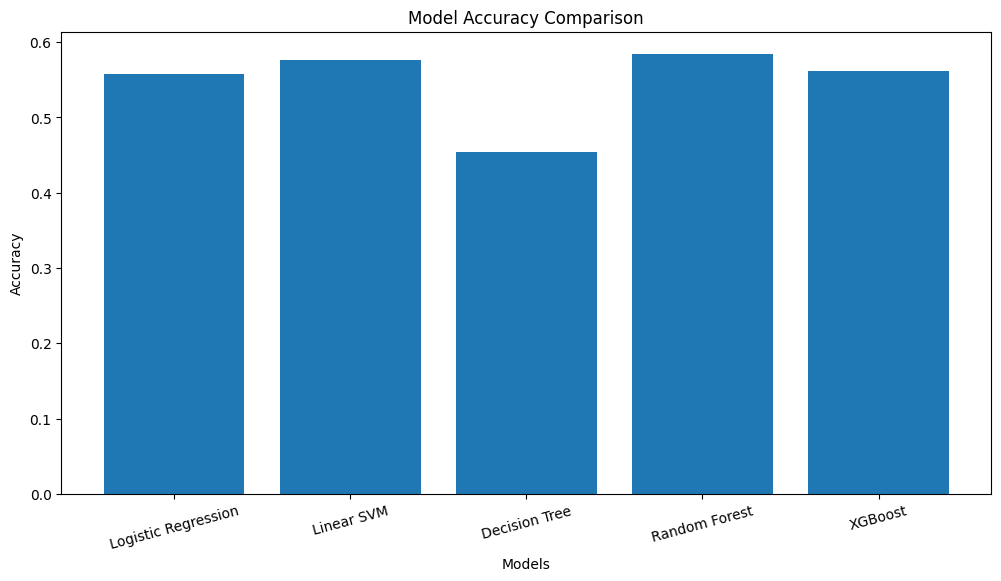

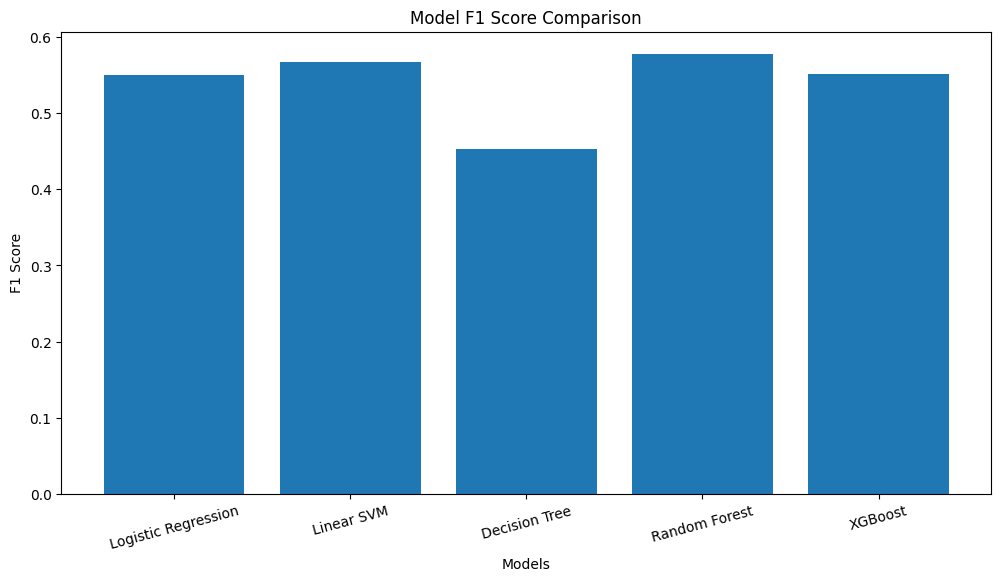

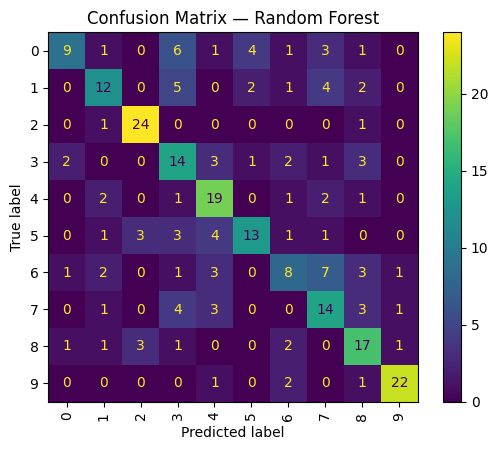


🚀 TOP-K ROOT CAUSE PREDICTION


In [2]:
print("\n================================================")
print("🚀 TOP-K ROOT CAUSE PREDICTION")
print("================================================")

if hasattr(best_model, "decision_function"):

    scores = best_model.decision_function(X_test)

    top_k = 3

    top_preds = np.argsort(scores, axis=1)[:, -top_k:]

    # Top-K Accuracy
    top_k_acc = np.mean([

        y_test.iloc[i]
        in best_model.classes_[top_preds[i]]

        for i in range(len(y_test))
    ])

    print(f"\n✅ Top-3 Accuracy: {top_k_acc:.4f}")

    # Example Predictions
    print("\nSample Top-3 Predictions:\n")

    for i in range(5):

        preds = best_model.classes_[top_preds[i]][::-1]

        print(f"Incident {i+1}: {preds}")
